In [1]:
%pip install matplotlib



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd 
import numpy as np
# pyrefly: ignore [missing-import]
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [11]:
df = pd.read_csv('/Users/ansartleubayev/Documents/20 projects /data/Almaty_PM2.5.csv')
df.head()

,value,coordinates,location_id,location_name,flagInfo.hasFlags,parameter.id,parameter.name,parameter.units,parameter.displayName,period.label,...,coverage.expectedCount,coverage.expectedInterval,coverage.observedCount,coverage.observedInterval,coverage.percentComplete,coverage.percentCoverage,coverage.datetimeFrom.utc,coverage.datetimeFrom.local,coverage.datetimeTo.utc,coverage.datetimeTo.local
0,91.5,NaN,8876,Almaty,False,2,pm25,µg/m³,NaN,1day,...,24,24:00:00,23,23:00:00,96.0,96.0,2024-12-31T20:00:00Z,2025-01-01T01:00:00+05:00,2025-01-01T19:00:00Z,2025-01-02T00:00:00+05:00
1,23.3,NaN,8876,Almaty,False,2,pm25,µg/m³,NaN,1day,...,24,24:00:00,24,24:00:00,100.0,100.0,2025-01-01T20:00:00Z,2025-01-02T01:00:00+05:00,2025-01-02T19:00:00Z,2025-01-03T00:00:00+05:00
2,73.0,NaN,8876,Almaty,False,2,pm25,µg/m³,NaN,1day,...,24,24:00:00,24,24:00:00,100.0,100.0,2025-01-02T20:00:00Z,2025-01-03T01:00:00+05:00,2025-01-03T19:00:00Z,2025-01-04T00:00:00+05:00
3,52.7,NaN,8876,Almaty,False,2,pm25,µg/m³,NaN,1day,...,24,24:00:00,24,24:00:00,100.0,100.0,2025-01-03T20:00:00Z,2025-01-04T01:00:00+05:00,2025-01-04T19:00:00Z,2025-01-05T00:00:00+05:00
4,30.2,NaN,8876,Almaty,False,2,pm25,µg/m³,NaN,1day,...,24,24:00:00,24,24:00:00,100.0,100.0,2025-01-04T20:00:00Z,2025-01-05T01:00:00+05:00,2025-01-05T19:00:00Z,2025-01-06T00:00:00+05:00


In [ ]:
df.columns

Index(['value', 'coordinates', 'location_id', 'location_name',
       'flagInfo.hasFlags', 'parameter.id', 'parameter.name',
       'parameter.units', 'parameter.displayName', 'period.label',
       'period.interval', 'period.datetimeFrom.utc',
       'period.datetimeFrom.local', 'period.datetimeTo.utc',
       'period.datetimeTo.local', 'summary.min', 'summary.q02', 'summary.q25',
       'summary.median', 'summary.q75', 'summary.q98', 'summary.max',
       'summary.avg', 'summary.sd', 'coverage.expectedCount',
       'coverage.expectedInterval', 'coverage.observedCount',
       'coverage.observedInterval', 'coverage.percentComplete',
       'coverage.percentCoverage', 'coverage.datetimeFrom.utc',
       'coverage.datetimeFrom.local', 'coverage.datetimeTo.utc',
       'coverage.datetimeTo.local'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18314 entries, 0 to 18313
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   value                        18314 non-null  float64
 1   coordinates                  0 non-null      float64
 2   location_id                  18314 non-null  int64  
 3   location_name                18314 non-null  str    
 4   flagInfo.hasFlags            18314 non-null  bool   
 5   parameter.id                 18314 non-null  int64  
 6   parameter.name               18314 non-null  str    
 7   parameter.units              18314 non-null  str    
 8   parameter.displayName        0 non-null      float64
 9   period.label                 18314 non-null  str    
 10  period.interval              18314 non-null  str    
 11  period.datetimeFrom.utc      18314 non-null  str    
 12  period.datetimeFrom.local    18314 non-null  str    
 13  period.datetimeTo.utc      

In [ ]:
df.coordinates.isna().sum() # no need for this column 

np.int64(18314)

In [4]:
numeric_df = df.select_dtypes(include='number')
categorical_df = df.select_dtypes(exclude='number') # i guess it's better to say non nummeric but anyway

In [ ]:
numeric_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18314 entries, 0 to 18313
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   value                     18314 non-null  float64
 1   coordinates               0 non-null      float64
 2   location_id               18314 non-null  int64  
 3   parameter.id              18314 non-null  int64  
 4   parameter.displayName     0 non-null      float64
 5   summary.min               18314 non-null  float64
 6   summary.q02               18314 non-null  float64
 7   summary.q25               18314 non-null  float64
 8   summary.median            18314 non-null  float64
 9   summary.q75               18314 non-null  float64
 10  summary.q98               18314 non-null  float64
 11  summary.max               18314 non-null  float64
 12  summary.avg               18314 non-null  float64
 13  summary.sd                18302 non-null  float64
 14  coverage.expected

In [ ]:
categorical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18314 entries, 0 to 18313
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   location_name                18314 non-null  str  
 1   flagInfo.hasFlags            18314 non-null  bool 
 2   parameter.name               18314 non-null  str  
 3   parameter.units              18314 non-null  str  
 4   period.label                 18314 non-null  str  
 5   period.interval              18314 non-null  str  
 6   period.datetimeFrom.utc      18314 non-null  str  
 7   period.datetimeFrom.local    18314 non-null  str  
 8   period.datetimeTo.utc        18314 non-null  str  
 9   period.datetimeTo.local      18314 non-null  str  
 10  coverage.expectedInterval    18314 non-null  str  
 11  coverage.observedInterval    18314 non-null  str  
 12  coverage.datetimeFrom.utc    18314 non-null  str  
 13  coverage.datetimeFrom.local  18314 non-null  str  
 14  c

<Figure size 1800x1000 with 0 Axes>

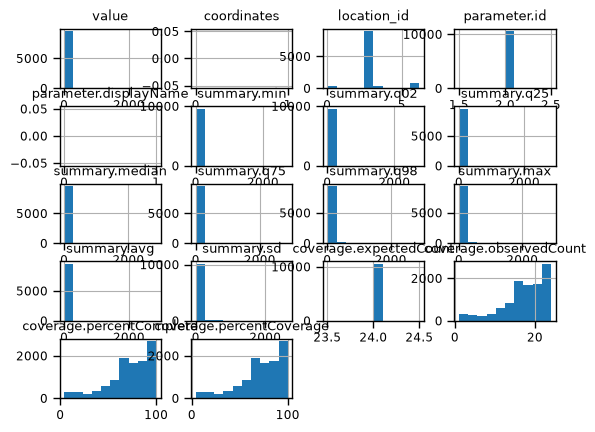

<Figure size 640x480 with 0 Axes>

In [5]:
sns.set_context(font_scale=1, context='paper')
plt.figure(figsize=(18, 10))
df.hist()
plt.show()
plt.tight_layout()

summary.min
0.000000     1790
0.100000      507
0.200000      318
0.300000      283
0.400000      217
             ... 
2.300000        1
0.529167        1
43.600000       1
7.200000        1
42.400000       1
Name: count, Length: 6137, dtype: int64

Breakdown of all the columns from your OpenAQ PM2.5 dataset:
Identification & Location

location_name — Name of the monitoring station
location_id — Unique numeric ID for that station
coordinates — Lat/lon of the station (appears to be empty/null for all rows though)

Parameter Info

parameter.id — Numeric ID of the measured pollutant
parameter.name — Name of the parameter (likely all "pm25" here)
parameter.units — Unit of measurement (probably µg/m³ for PM2.5)
parameter.displayName — Human-readable name (also appears fully null)

Time Period

period.label — A label for the aggregation period (e.g. "2024", "January")
period.interval — Duration of the period (e.g. "P1Y", "P1M" in ISO 8601)
period.datetimeFrom.utc / .local — Start of the measurement window, in UTC and local time
period.datetimeTo.utc / .local — End of the measurement window

Statistical Summary (all for PM2.5 concentration in that period)

value — Likely the primary/representative value (possibly the mean or latest)
summary.min / .max — Minimum and maximum recorded values
summary.q02 / .q25 / .median / .q75 / .q98 — Percentiles (2nd, 25th, 50th, 75th, 98th)
summary.avg — Average concentration
summary.sd — Standard deviation

Data Coverage (how complete the data is for that period)

coverage.expectedCount — How many readings were expected
coverage.observedCount — How many were actually recorded
coverage.percentComplete — % of expected readings that arrived
coverage.percentCoverage — Similar coverage metric (may differ by methodology)
coverage.expectedInterval / .observedInterval — The time resolution expected vs. observed (e.g. "PT1H")
coverage.datetimeFrom / .datetimeTo — The actual time window the coverage calculation spans
flagInfo.hasFlags — Whether any data quality flags were raised for this record

In [7]:
len(df)

10509

0        24:00:00
1        24:00:00
2        24:00:00
3        24:00:00
4        24:00:00
           ...   
10504    24:00:00
10505    24:00:00
10506    24:00:00
10507    24:00:00
10508    24:00:00
Name: period.interval, Length: 10509, dtype: str

In [15]:
df['period.interval'].dtypes

<StringDtype(storage='python', na_value=nan)>

In [9]:
df['period.label'].value_counts()

period.label
1day    10509
Name: count, dtype: int64

In [25]:
df['period.datetimeTo.local'] = pd.to_datetime(df['period.datetimeTo.local'], errors='coerce')
def season_convert(x):
    if pd.isna(x):
        return 'unknown'
    if x in [1,2,12]:
        return 'winter'
    elif x in [3,4,5]:
        return 'spring'
    elif x in [6,7,8]:
        return 'summer'
    else:
        return 'autumn'

In [21]:
df['period.datetimeTo.local']

0       2025-01-02 00:00:00+05:00
1       2025-01-03 00:00:00+05:00
2       2025-01-04 00:00:00+05:00
3       2025-01-05 00:00:00+05:00
4       2025-01-06 00:00:00+05:00
                   ...           
10504   2025-12-29 00:00:00+05:00
10505   2025-12-30 00:00:00+05:00
10506   2025-12-31 00:00:00+05:00
10507   2026-01-01 00:00:00+05:00
10508   2026-01-02 00:00:00+05:00
Name: period.datetimeTo.local, Length: 10509, dtype: datetime64[us, UTC+05:00]

0        24:00:00
1        24:00:00
2        24:00:00
3        24:00:00
4        24:00:00
           ...   
10504    24:00:00
10505    24:00:00
10506    24:00:00
10507    24:00:00
10508    24:00:00
Name: period.interval, Length: 10509, dtype: str

In [26]:
# basically to predict future PM25 values we don't need features about identification&location, parameter info and time periods except the season so we have to create additional feature for it 
df['season'] = df['period.datetimeTo.local'].dt.month.apply(season_convert)
# .month on a Pandas Series (a column), it extracts the month component from each datetime value as an integer from 1 to 12

In [27]:
df.season.value_counts()

season
spring    2978
winter    2939
summer    2868
autumn    1724
Name: count, dtype: int64

In [28]:
df.sample(3)

,value,coordinates,location_id,location_name,flagInfo.hasFlags,parameter.id,parameter.name,parameter.units,parameter.displayName,period.label,...,coverage.expectedInterval,coverage.observedCount,coverage.observedInterval,coverage.percentComplete,coverage.percentCoverage,coverage.datetimeFrom.utc,coverage.datetimeFrom.local,coverage.datetimeTo.utc,coverage.datetimeTo.local,season
9968,76.2,NaN,6175397,Sairan (Qarasai Batyr k-si),False,2,pm25,µg/m³,NaN,1day,...,24:00:00,22,22:00:00,92.0,92.0,2025-12-29T20:00:00Z,2025-12-30T01:00:00+05:00,2025-12-30T18:00:00Z,2025-12-30T23:00:00+05:00,winter
1791,44.3,NaN,2812632,Elaman 105 St.,False,2,pm25,µg/m³,NaN,1day,...,24:00:00,3,03:00:00,13.0,13.0,2025-02-02T19:01:12Z,2025-02-03T00:01:12+05:00,2025-02-03T08:59:19Z,2025-02-03T13:59:19+05:00,winter
1647,14.1,NaN,2812620,Alatau,False,2,pm25,µg/m³,NaN,1day,...,24:00:00,14,14:00:00,58.0,58.0,2025-06-27T19:09:20Z,2025-06-28T00:09:20+05:00,2025-06-28T18:45:25Z,2025-06-28T23:45:25+05:00,summer


In [32]:
df.columns

Index(['value', 'coordinates', 'location_id', 'location_name',
       'flagInfo.hasFlags', 'parameter.id', 'parameter.name',
       'parameter.units', 'parameter.displayName', 'period.label',
       'period.interval', 'period.datetimeFrom.utc',
       'period.datetimeFrom.local', 'period.datetimeTo.utc',
       'period.datetimeTo.local', 'summary.min', 'summary.q02', 'summary.q25',
       'summary.median', 'summary.q75', 'summary.q98', 'summary.max',
       'summary.avg', 'summary.sd', 'coverage.expectedCount',
       'coverage.expectedInterval', 'coverage.observedCount',
       'coverage.observedInterval', 'coverage.percentComplete',
       'coverage.percentCoverage', 'coverage.datetimeFrom.utc',
       'coverage.datetimeFrom.local', 'coverage.datetimeTo.utc',
       'coverage.datetimeTo.local', 'season'],
      dtype='str')

In [40]:
# okay here is the data that doesn't make any sense to our goal 2 of them are even have no values at all 
# basically to predict future PM25 values we don't need features about identification&location(except location name), parameter info and time periods except the season so we have to create additional feature for it 
clean_df = df.drop(columns=['coordinates', 'parameter.displayName', 'location_id', 'parameter.id', 'parameter.name', 'parameter.units', 'parameter.displayName', 'parameter.displayName', 'period.label', 'period.interval', 'period.datetimeFrom.local', 'period.datetimeTo.utc', 'period.datetimeTo.local', 'period.datetimeFrom.utc', 'coverage.datetimeFrom.utc', 'coverage.datetimeFrom.local', 'coverage.datetimeTo.utc', 'coverage.datetimeTo.local']) 

In [41]:
clean_df.sample(3)

,value,location_name,flagInfo.hasFlags,summary.min,summary.q02,summary.q25,summary.median,summary.q75,summary.q98,summary.max,summary.avg,summary.sd,coverage.expectedCount,coverage.expectedInterval,coverage.observedCount,coverage.observedInterval,coverage.percentComplete,coverage.percentCoverage,season
4323,84.80,169 School,True,14.7525,15.046317,18.780625,22.830000,110.906250,367.198833,437.8650,84.825000,392.277140,24,24:00:00,19,19:00:00,79.0,79.0,spring
3440,9.78,KBTU,False,5.5600,5.612200,6.663333,7.836667,10.823333,21.379600,22.6675,9.778684,4.717528,24,24:00:00,19,19:00:00,79.0,79.0,spring
1007,18.10,Kokzhiyek-63,False,7.8100,8.047000,10.157500,14.207500,26.817500,32.008000,32.0300,18.050677,9.347333,24,24:00:00,16,16:00:00,67.0,67.0,summer


In [42]:
clean_df.isna().sum()

value                        928
location_name                  0
flagInfo.hasFlags              0
summary.min                  928
summary.q02                  928
summary.q25                  928
summary.median               928
summary.q75                  928
summary.q98                  928
summary.max                  928
summary.avg                  928
summary.sd                   100
coverage.expectedCount         0
coverage.expectedInterval      0
coverage.observedCount         0
coverage.observedInterval      0
coverage.percentComplete       0
coverage.percentCoverage       0
season                         0
dtype: int64